### ==============================================================================
## Processing of Moving Vessel Profiler Data - code 2_lag_vs_descent_rate
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Data from FaSt-SWOT experiment
# 
**DESCRIPTION**:
 This script performs Step 2: Lag Analysis. It calculates the fractional lag 
 between Temperature and Conductivity sensors to correct for spatial/temporal 
 mismatch. It segments the profiles into windows and computes the cross-correlation. 
 For FaSt-SWOT Leg 1, it automatically classifies profiles into 'Normal' and 
 'Anomaly' regimes based on median lag thresholds (handling dirty sensor events).
 Finally, it fits a linear regression model (Lag vs. Descent Rate w) for each regime.
#
 INPUT: QC'd NetCDF files from Step 1 (*_step1_qc.nc).
 #
 OUTPUT: CSV with profile regimes, CSV with lag models, and a 3-panel validation plot.
### ==============================================================================

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


 [PART A] Calculating lags per segment...


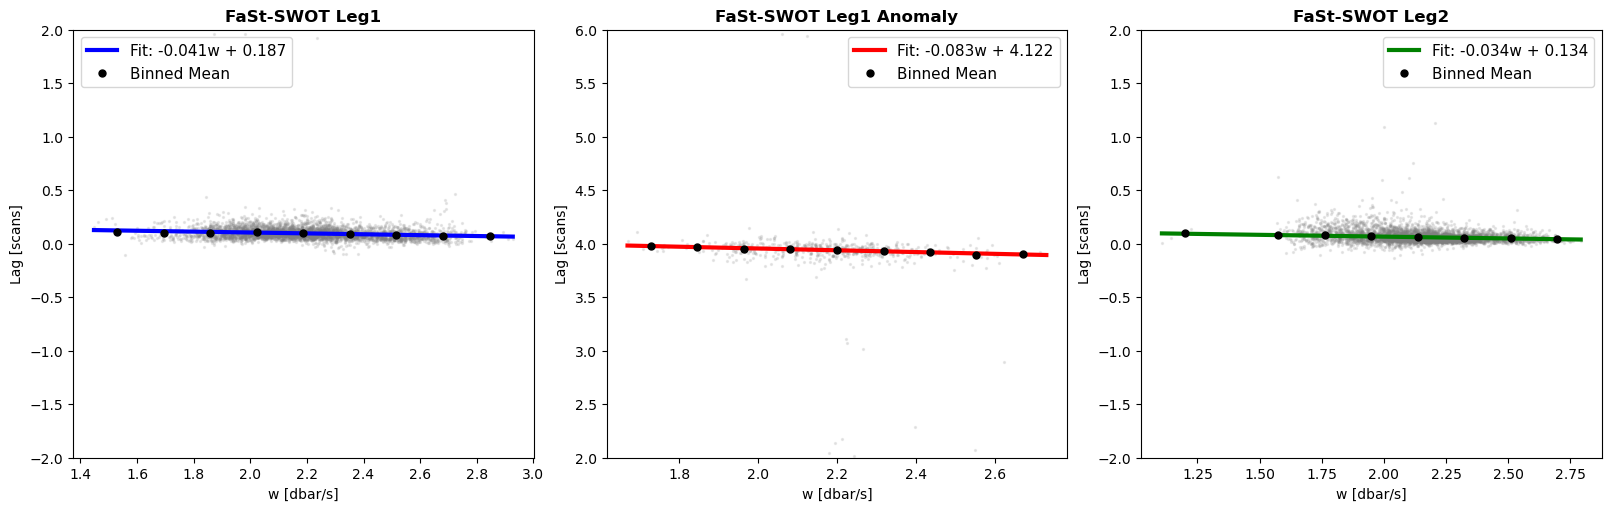

✅ Step 2 completed. Models and plots saved to C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing\Figures\STEP2_LAG_ANALYSIS_SEGMENTS


In [1]:

import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_ROOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")
LEGS = {
    "FaSt_Leg1": BASE_ROOT / "Data" / "Leg1" / "processed_step1_highres_qc",
    "FaSt_Leg2": BASE_ROOT / "Data" / "Leg2" / "processed_step1_highres_qc"
}

OUT_DIR = BASE_ROOT / "Figures" /"STEP2_LAG_ANALYSIS_SEGMENTS"
OUT_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 125    
STEP_SIZE = WINDOW_SIZE // 2  
MAX_LAG_SEARCH = 10  
MIN_CORR = 0.8      

SPLIT_THRESHOLD_LEG1 = 1.5   # to split Leg 1 into "Normal" and "Anomaly" based on median lag in the check depth range
DEPTH_MIN_CHECK = 10.0       
DEPTH_MAX_CHECK = 80.0       

# ==========================================
# 2. FUNCTIONS
# ==========================================
def calculate_fractional_lag(t_seg, c_seg):
    """Calculates fractional lag between two segments using cross-correlation and parabolic fit."""
    t_seg = t_seg - np.mean(t_seg)
    c_seg = c_seg - np.mean(c_seg)
    lags = np.arange(-MAX_LAG_SEARCH, MAX_LAG_SEARCH + 1)
    corrs = []
    
    for lag in lags:
        if lag < 0: 
            c_shift = c_seg[-lag:]
            t_cut = t_seg[:len(c_shift)]
        elif lag > 0: 
            c_shift = c_seg[:-lag]
            t_cut = t_seg[lag:]
        else: 
            c_shift = c_seg
            t_cut = t_seg
            
        if len(c_shift) > 10:
            norm = np.std(t_cut) * np.std(c_shift)
            val = np.mean(t_cut * c_shift) / norm if norm > 1e-9 else 0
        else: 
            val = 0
            
        corrs.append(val)
        
    corrs = np.array(corrs)
    idx_max = np.argmax(corrs)
    
    if 0 < idx_max < len(corrs) - 1:
        y = corrs[idx_max-1 : idx_max+2]
        x = lags[idx_max-1 : idx_max+2]
        try:
            coeffs = np.polyfit(x, y, 2)
            if coeffs[0] < 0: 
                return -coeffs[1] / (2 * coeffs[0]), corrs[idx_max]
        except: 
            pass
            
    return float(lags[idx_max]), corrs[idx_max]

def remove_outliers_iqr(df, col='lag_scans'):
    """Removes statistical outliers from a dataframe column using the IQR method."""
    if len(df) < 3: return df
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

# ==========================================
# 3. PROCESSING
# ==========================================
print(" [PART A] Calculating lags per segment...")
results = []
all_files_leg1 = []

for leg_name, path in LEGS.items():
    if not path.exists(): continue
    files = sorted(list(path.glob("*.nc")))
    
    for f in files:
        if "Leg1" in leg_name: 
            all_files_leg1.append(f.name)
            
        try:
            with xr.open_dataset(f) as ds:
                p, t, c, w = ds.pressure.values, ds.t1.values, ds.c1.values, ds.w_descent.values
                mask = (p > 5) & (p < 250)
                p, t, c, w = p[mask], t[mask], c[mask], w[mask]
                
                for i in range(0, len(p) - WINDOW_SIZE, STEP_SIZE):
                    t_s, c_s, w_s, p_s = t[i:i+WINDOW_SIZE], c[i:i+WINDOW_SIZE], w[i:i+WINDOW_SIZE], p[i:i+WINDOW_SIZE]
                    if np.nanmean(w_s) < 0.2: continue
                    if np.std(np.diff(t_s)) < 0.0001: continue
                    
                    lag, corr = calculate_fractional_lag(np.diff(t_s), np.diff(c_s))
                    if corr >= MIN_CORR and abs(lag) < MAX_LAG_SEARCH:
                        results.append({
                            'dataset': leg_name, 
                            'file': f.name, 
                            'pressure_mean': np.mean(p_s), 
                            'w_mean': np.mean(w_s), 
                            'lag_scans': lag
                        })
        except: 
            continue

df = pd.DataFrame(results)
df_leg1 = df[df['dataset'] == 'FaSt_Leg1']
df_check = df_leg1[(df_leg1['pressure_mean'] >= DEPTH_MIN_CHECK) & (df_leg1['pressure_mean'] <= DEPTH_MAX_CHECK)]
file_medians = df_check.groupby('file')['lag_scans'].median()

files_anomaly = file_medians[file_medians > SPLIT_THRESHOLD_LEG1].index.tolist()
files_normal  = file_medians[file_medians <= SPLIT_THRESHOLD_LEG1].index.tolist()

# Reinforced logic: Leg 1 files without enough data are considered anomalous as a precaution
classified = set(files_anomaly + files_normal)
for f in all_files_leg1:
    if f not in classified:
        files_anomaly.append(f) # If no clear data, mark as anomaly (possibly a very dirty sensor)

regime_map = []
for f in files_normal: regime_map.append({'file': f, 'regime': 'Leg1_Normal'})
for f in files_anomaly: regime_map.append({'file': f, 'regime': 'Leg1_Anomaly'})
for f in df[df['dataset'] == 'FaSt_Leg2']['file'].unique(): regime_map.append({'file': f, 'regime': 'Leg2_Standard'})

pd.DataFrame(regime_map).to_csv(OUT_DIR / "profile_regimes.csv", index=False)

df['plot_group'] = np.nan
df.loc[(df['dataset'] == 'FaSt_Leg1') & (df['file'].isin(files_normal)), 'plot_group'] = 'FaSt-SWOT Leg1'
df.loc[(df['dataset'] == 'FaSt_Leg1') & (df['file'].isin(files_anomaly)), 'plot_group'] = 'FaSt-SWOT Leg1 Anomaly'
df.loc[(df['dataset'] == 'FaSt_Leg2'), 'plot_group'] = 'FaSt-SWOT Leg2'

# ==========================================
# 4. PLOT AND MODELS
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
groups = [('FaSt-SWOT Leg1', 'blue'), ('FaSt-SWOT Leg1 Anomaly', 'red'), ('FaSt-SWOT Leg2', 'green')]
model_results = []

for i, (group_name, color) in enumerate(groups):
    d_sub = df[df['plot_group'] == group_name]
    ax = axs[i]
    if not d_sub.empty:
        ax.scatter(d_sub['w_mean'], d_sub['lag_scans'], c='gray', s=2, alpha=0.15)
        d_clean = remove_outliers_iqr(d_sub)
        
        if len(d_clean) > 5:
            slope, intercept, r, p_val, err = linregress(d_clean['w_mean'], d_clean['lag_scans'])
            model_results.append({'regime': group_name, 'slope': slope, 'intercept': intercept})
            x_vals = np.array([d_clean['w_mean'].min(), d_clean['w_mean'].max()])
            ax.plot(x_vals, slope*x_vals + intercept, color=color, lw=3, label=f"Fit: {slope:.3f}w + {intercept:.3f}")
            
            bins = np.linspace(d_clean['w_mean'].min(), d_clean['w_mean'].max(), 10)
            binned = d_clean.groupby(pd.cut(d_clean['w_mean'], bins))['lag_scans'].mean()
            ax.plot([b.mid for b in binned.dropna().index], binned.dropna().values, 'ko', ms=5, label='Binned Mean')
            
    ax.set_title(group_name, fontweight='bold')
    ax.set_ylim(2, 6) if 'Anomaly' in group_name else ax.set_ylim(-2, 2)
    ax.legend(fontsize=11)
    ax.set_xlabel('w [dbar/s]')
    ax.set_ylabel('Lag [scans]')

pd.DataFrame(model_results).to_csv(OUT_DIR / "lag_models_step2.csv", index=False)
plt.savefig(OUT_DIR / "lag_vs_w_step2.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Step 2 completed. Models and plots saved to {OUT_DIR}")